In [ ]:
# This entire file is just used for sanity checks on table output

import duckdb
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

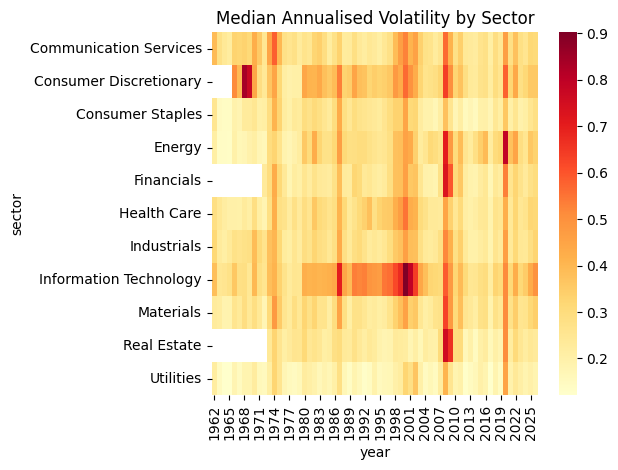

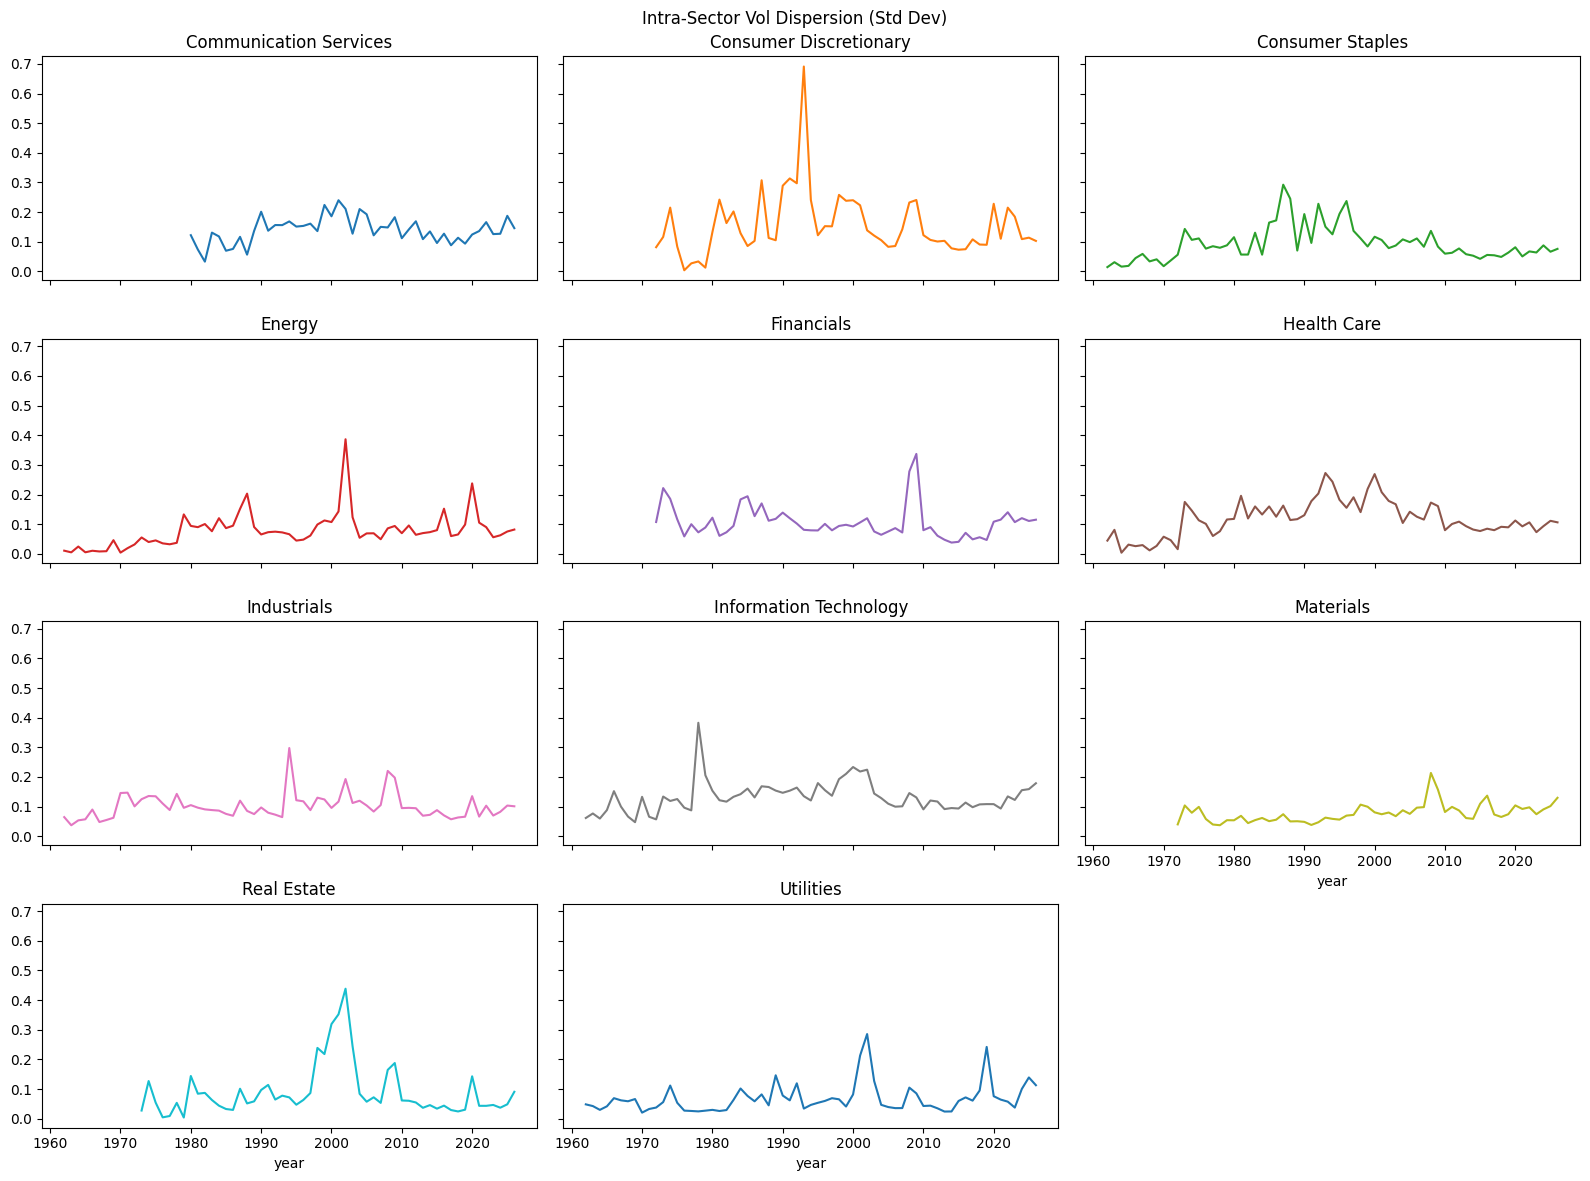

NameError: name 'ranks' is not defined

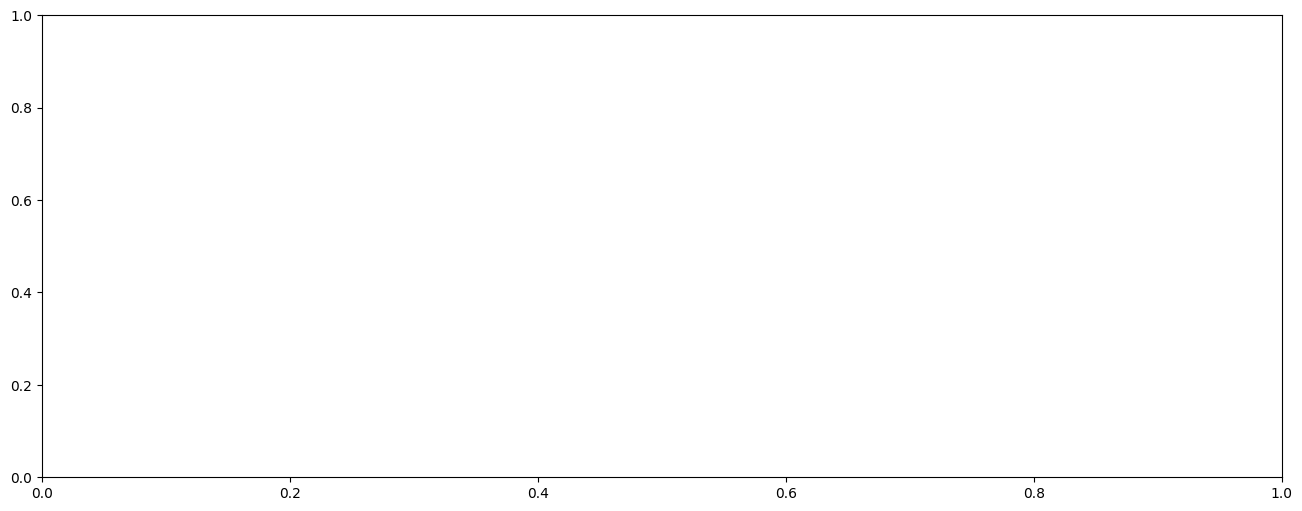

In [7]:
# Analysis for mart_snp500_annualised_volatility

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"

with duckdb.connect(str(db_path)) as con:
    vol = con.execute("SELECT * FROM mart_snp500_annualised_volatility").df()

# 1. Sector volatility over time
pivot = vol.pivot_table(index="sector", columns="year", values="annualised_volatility", aggfunc="median")
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Median Annualised Volatility by Sector")
plt.tight_layout()
plt.show()

# 2. Intra-sector vol dispersion
disp = vol.groupby(["year", "sector"])["annualised_volatility"].std().unstack()
axes = disp.plot(subplots=True, layout=(4, 3), figsize=(16, 12), sharey=True, legend=False)
for ax, sector in zip(axes.flatten(), disp.columns):
    ax.set_title(sector)
plt.suptitle("Intra-Sector Vol Dispersion (Std Dev)")
plt.tight_layout()
plt.show()

# 3. Sector vol rank stability
fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(ranks.T, cmap="YlOrRd", ax=ax)
plt.title("Sector Vol Rank by Year (1 = lowest)")
plt.tight_layout()
plt.show()

# Volatility is structurally concentrated in the same sectors (Tech, Energy, Consumer Discretionary) that stay consistently top-ranked year after year, while dispersion spikes during crises reveal that even within those sectors, a few names drive the extremes.

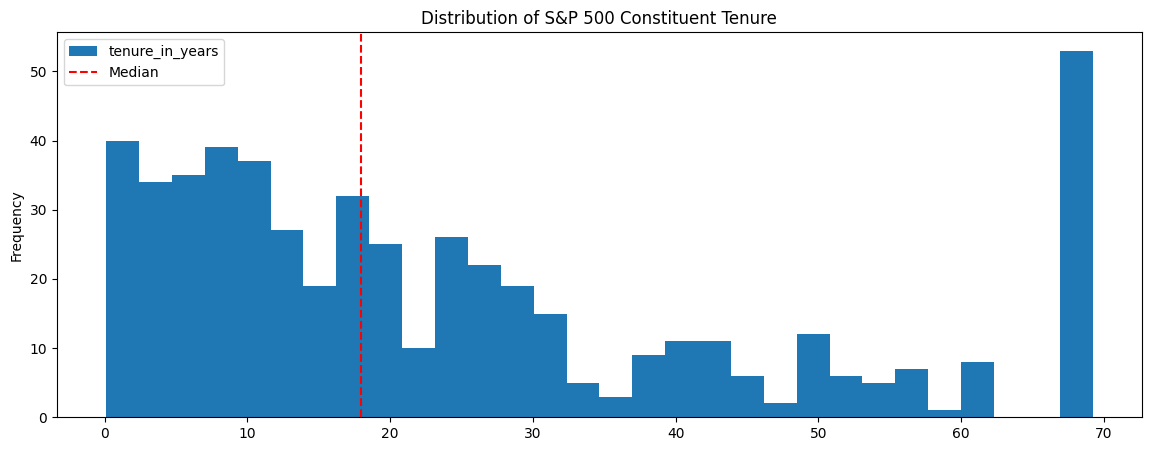

In [ ]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"

with duckdb.connect(str(db_path)) as con:
    tenure = con.execute("SELECT * FROM mart_snp500_current_constituent_tenure").df()

tenure["tenure_in_years"].plot.hist(bins=30, figsize=(14, 5))
plt.axvline(tenure["tenure_in_years"].median(), color="red", linestyle="--", label="Median")
plt.title("Distribution of S&P 500 Constituent Tenure")
plt.legend()
plt.show()

# The median S&P 500 constituent has been in the index for only ~20 years, with most tenures clustered under 15 — but a survivor cohort at ~65+ years shows the index is split between constant churn and a core of legacy incumbents.

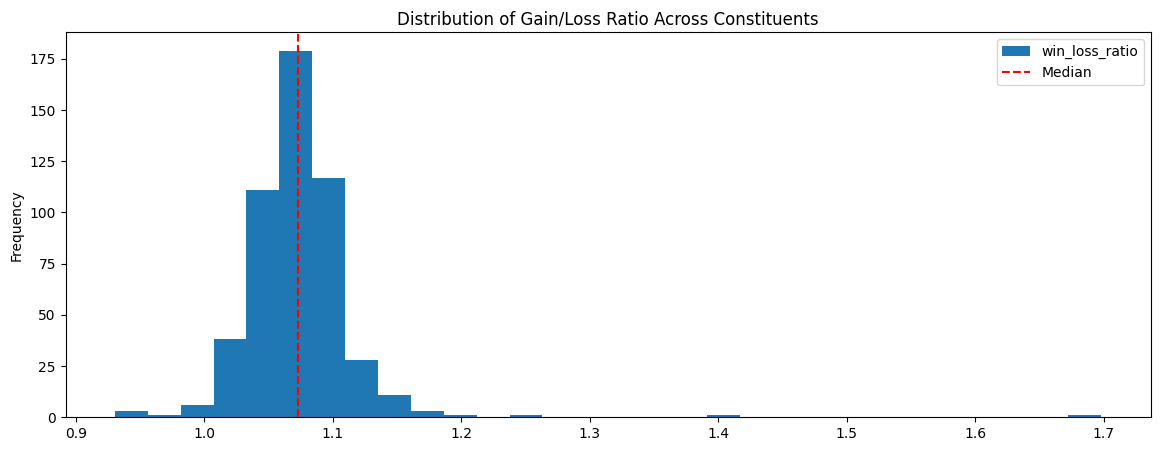

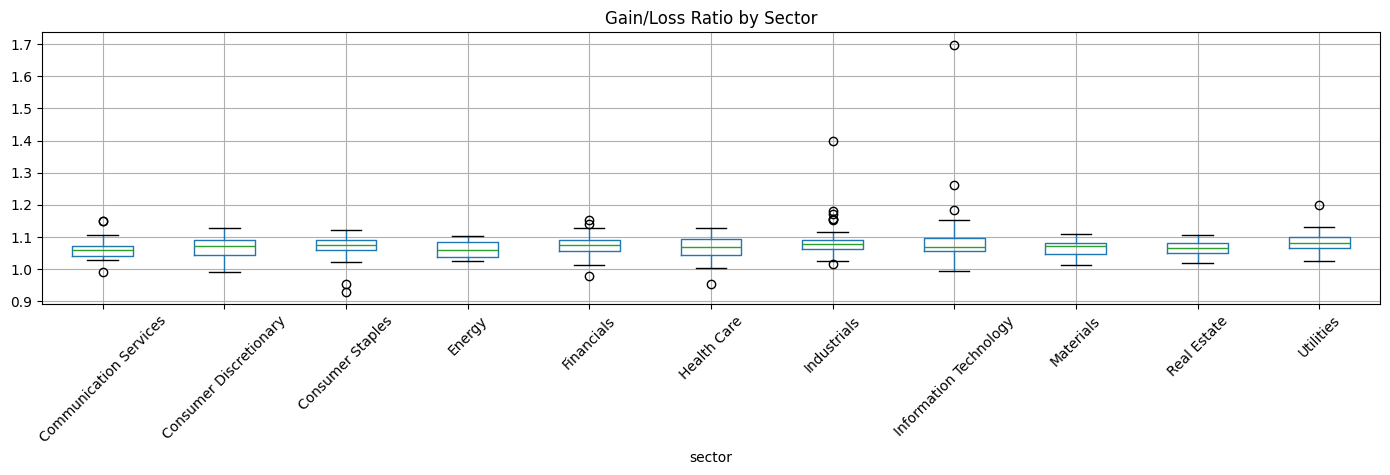

In [ ]:
# Analysis of mart_snp500_gain_loss_ratio

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"

with duckdb.connect(str(db_path)) as con:
    ratio = con.execute("SELECT * FROM mart_snp500_gain_loss_ratio").df()

# 1. Distribution of gain/loss ratio across all tickers
ratio["win_loss_ratio"].plot.hist(bins=30, figsize=(14, 5))
plt.axvline(ratio["win_loss_ratio"].median(), color="red", linestyle="--", label="Median")
plt.title("Distribution of Gain/Loss Ratio Across Constituents")
plt.legend()
plt.show()

# 2. By sector
ratio.boxplot(column="win_loss_ratio", by="sector", figsize=(14, 5), rot=45)
plt.title("Gain/Loss Ratio by Sector")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Return concentration isn't driven by winning more often — nearly all constituents win at similar rates (~1.08) regardless of sector — but by a few outliers in Tech and Health Care winning disproportionately bigger.

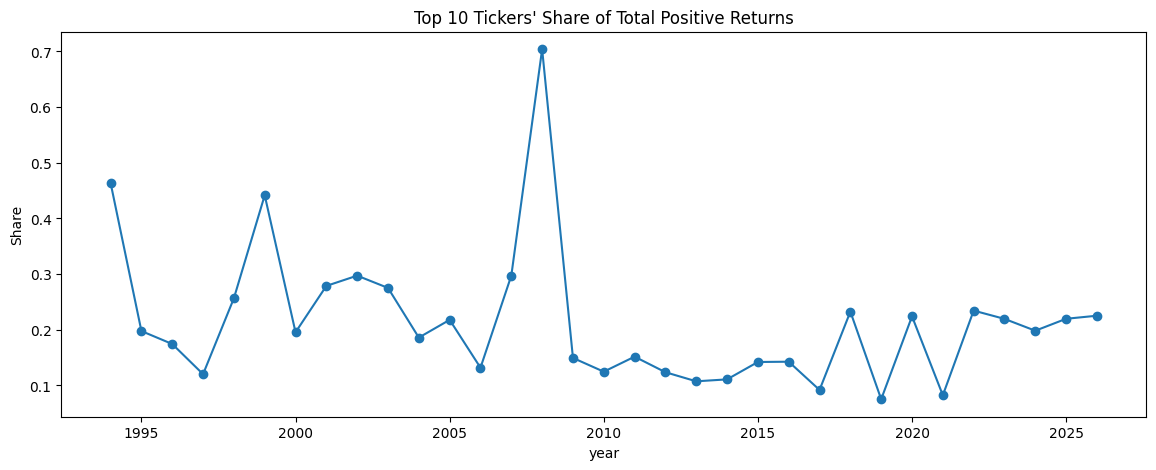

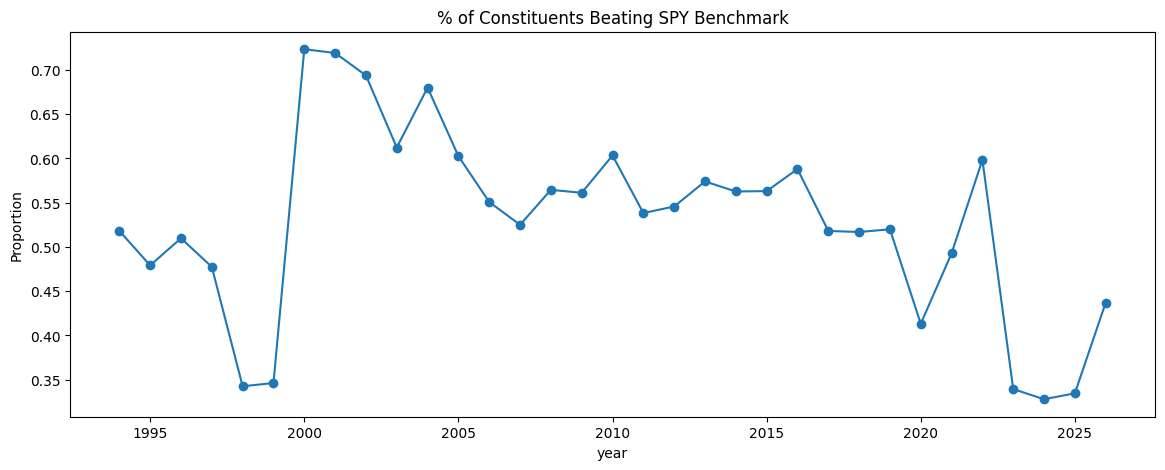

In [ ]:
# Analysis of mart_snp500_return_concentration

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"

with duckdb.connect(str(db_path)) as con:
    returns = con.execute("SELECT * FROM mart_snp500_return_concentration").df()

# 1. Top 10 vs rest: what % of total positive returns do the top 10 tickers capture each year?
pos = returns[returns["pct_change_in_adj_close"] > 0].copy()
pos["total_pos_return"] = pos.groupby("year")["pct_change_in_adj_close"].transform("sum")
pos["rank"] = pos.groupby("year")["pct_change_in_adj_close"].rank(ascending=False)
top10_share = pos[pos["rank"] <= 10].groupby("year")["pct_change_in_adj_close"].sum() / pos.groupby("year")["pct_change_in_adj_close"].sum()
top10_share.plot(figsize=(14, 5), marker="o")
plt.title("Top 10 Tickers' Share of Total Positive Returns")
plt.ylabel("Share")
plt.show()

# 2. % of constituents that beat SPY each year
beat_pct = returns.groupby("year")["beat_benchmark_flag"].mean()
beat_pct.plot(figsize=(14, 5), marker="o")
plt.title("% of Constituents Beating SPY Benchmark")
plt.ylabel("Proportion")
plt.show()

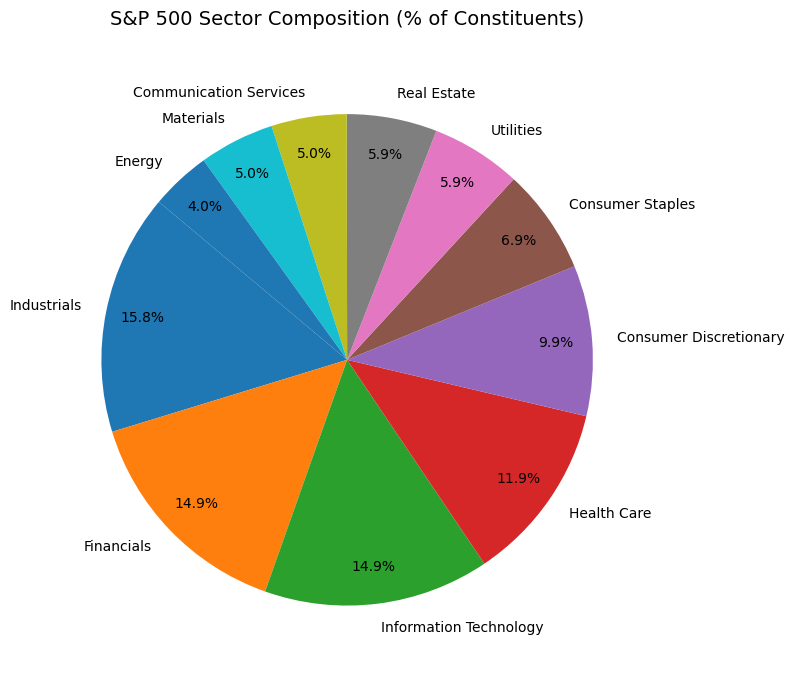

In [1]:
# Analysis of mart_snp500_sector_composition

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"

with duckdb.connect(str(db_path)) as con:
    comp = con.execute("SELECT * FROM mart_snp500_sector_composition").df()

comp = comp.sort_values(by='percentage_of_companies', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    comp['percentage_of_companies'],
    labels=comp['sector'],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85
)

ax.set_title('S&P 500 Sector Composition (% of Constituents)', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

C:\Users\Winst\OneDrive\Desktop\Winston_Project_Folder\data\warehouse.duckdb


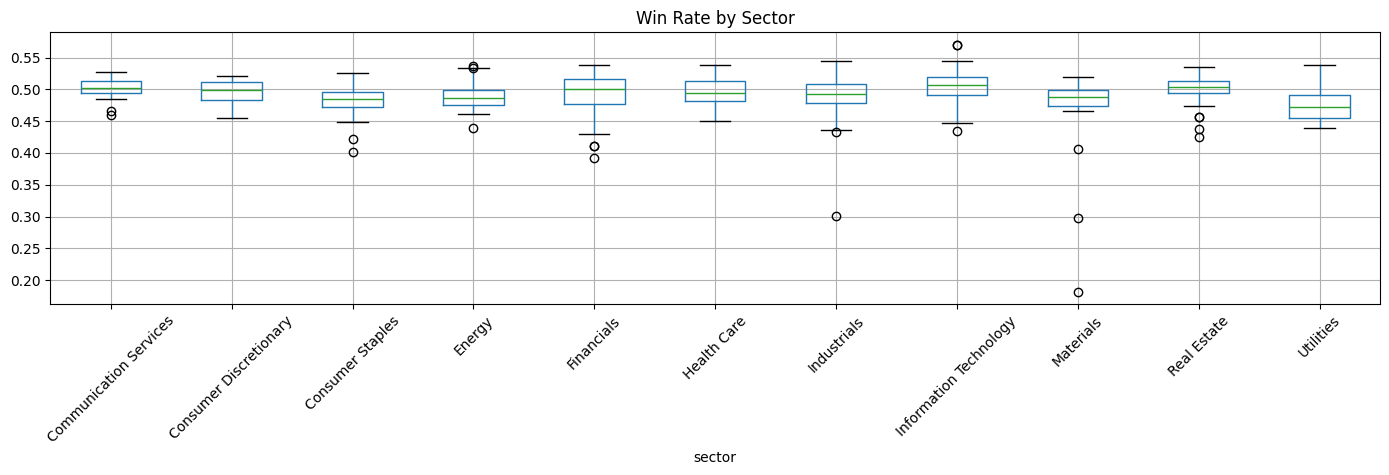

In [ ]:
# Analysis of mart_snp500_win_rate

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"
print(db_path.resolve())  # verify it matches the scrape script's path

with duckdb.connect(str(db_path)) as con:

    win_rate = con.execute("""select * from mart_snp500_win_rate""").df()
    
win_rate.boxplot(column="win_rate", by="sector", figsize=(14, 5), rot=45)
plt.title("Win Rate by Sector")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Win rates cluster tightly around 50% across all sectors — stock picking is essentially a coin flip, reinforcing that returns are driven by magnitude of wins, not frequency.

In [23]:
# View tables

db_path = Path.cwd().parent / "data" / "warehouse.duckdb"
print(db_path.resolve())  # verify it matches the scrape script's path

with duckdb.connect(str(db_path)) as con:

    df = con.execute("""select * from snp500_spy_prices""").df()

  
    
df

C:\Users\Winst\OneDrive\Desktop\Winston_Project_Folder\data\warehouse.duckdb


CatalogException: Catalog Error: Table with name snp500_spy_prices does not exist!
Did you mean "snp500_raw_prices"?

LINE 1: select * from snp500_spy_prices
                      ^

Dropped snp500_spy_prices
